# Imports

In [4]:
# libraries
import networkx as nx
import random
import matplotlib
import matplotlib.pyplot as plt
import time
# our code
from solver import squared_distance, BTSPSolverCP
from BTSP.test import solver_test

# Bottleneck Traveling Salesman Problem
The Bottleneck Traveling Salesman Problem (BTSP) is a variation of the classical Traveling Salesman Problem (TSP) where the objective is to minimize the cost of the most expensive edge used in the tour.

*More formally, given a complete graph G=(V,E) with non-negative edge weights d_{ij} for all i,j\in V, the goal is to find a Hamiltonian cycle C in G such that the weight of the heaviest edge in C is minimized.

*Sei H_G = {C_1 … C_n} die Menge von Hamiltonian cycle in G.
Suche ein C in H_G, sodass max(e) von C <= max(e ) von C_i in H_G, C_i != C

## Utils

In [5]:
def random_points(n, w=10_000, h=10_000):
    """
    Generate a list of n randomly placed points on the w x h grid.
    """
    return [(random.randint(0,w), random.randint(0,h)) for _ in range(n)]

def draw_btsp_edges(edges):
    """
    Draw the edges of a DBST. The bottleneck edge(s) automatically get highlighted.
    """
    points = set([e[0] for e in edges] + [e[1] for e in edges])
    draw_graph = nx.empty_graph()
    draw_graph.add_nodes_from(points)
    draw_graph.add_edges_from(edges)
    g_edges = draw_graph.edges()
    max_length = max((squared_distance(*e) for e in g_edges))
    color = [('red' if squared_distance(*e) == max_length else 'black') for e in g_edges]
    width = [(1.0 if squared_distance(*e) == max_length else 0.5) for e in g_edges]
    plt.clf()
    fig, ax = plt.gcf(), plt.gca()
    fig.set_size_inches(8,8)
    ax.set_aspect(1.0)  # 1:1 aspect ratio
    nx.draw_networkx(draw_graph, pos={p: p for p in points}, node_size=8,
                     with_labels=False, edgelist=g_edges, edge_color=color, width=width, ax=ax)
    plt.show()

## Solve something

solving instance:  50
current size:  0
0.6727509498596191
solving instance:  51
current size:  1
0.5918657779693604
solving instance:  52
current size:  2
0.7629361152648926
solving instance:  53
current size:  3
0.7188320159912109
solving instance:  54
current size:  4
0.991265058517456
solving instance:  55
current size:  5
0.9463398456573486
solving instance:  56
current size:  6
0.8678257465362549
solving instance:  57
current size:  7
1.0708441734313965
solving instance:  58
current size:  8
0.9840309619903564
solving instance:  59
current size:  9
1.188448190689087
solving instance:  60
current size:  10
0.818371057510376
solving instance:  61
current size:  11
1.1616261005401611
solving instance:  62
current size:  12
1.3671598434448242
solving instance:  63
current size:  13
1.314913034439087
solving instance:  64
current size:  14
1.6347148418426514
solving instance:  65
current size:  15
1.9211111068725586
solving instance:  66
current size:  16
2.009833812713623
solving inst

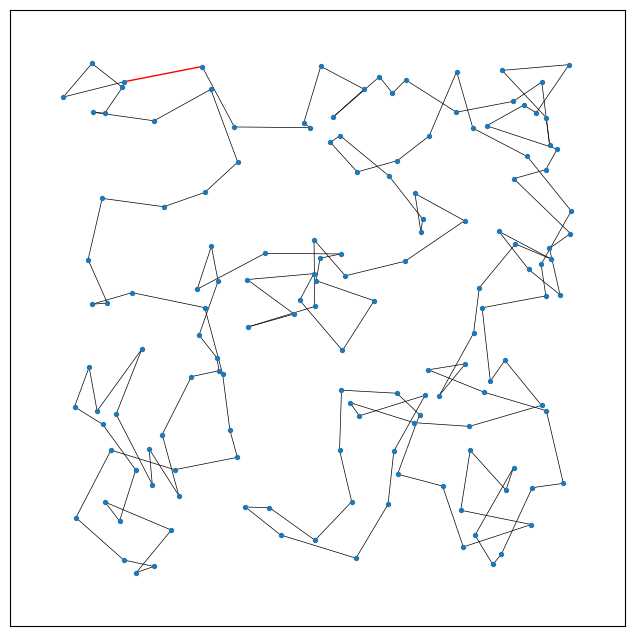

In [6]:
#random.seed(1234567) # remove if you want random instances
#solver = BTSPSolverCP(random_points(1000),1)
#start_time = time.time()
#result = solver.solve()
#end_time = time.time()
#print(end_time-start_time)
def param_generator():
    num_nodes = 50
    increment = 1
    while True:
        yield num_nodes, random_points(num_nodes)
        num_nodes += increment
generator = param_generator()
# 0 : not using the circuit constraint
#results_0 = solver_test(60,100,BTSPSolverCP,generator,0)
#print(len(results_0[-1]))
#draw_btsp_edges(results_0[-1])
results_1 = solver_test(60,100,BTSPSolverCP,generator,0)
print(len(results_1[-1]))
draw_btsp_edges(results_1[-1])
#draw_btsp_edges(result)